<a href="https://colab.research.google.com/github/CIDE7/Ciencia-de-daos-iesb/blob/main/Vacinacao_2026_feito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados de Vacinação no Brasil - 2026

## Introdução

Os dados utilizados neste trabalho foram coletados em junho de 2026. Como a base é atualizada continuamente, os resultados podem apresentar diferenças em consultas realizadas em datas posteriores. Portanto, as análises apresentadas refletem exclusivamente o conjunto de dados disponível no momento da coleta. Os dados contêm informações sobre doses aplicadas, características dos pacientes e dos estabelecimentos de saúde responsáveis pela vacinação.

A base contém registros de vacinação entre janeiro e Maio de 2026.

O conjunto de dados pode ser classificado como dados estruturados, pois as informações estão organizadas em linhas e colunas, facilitando sua manipulação e análise utilizando ferramentas como Python e Pandas.

A escolha desse tema foi motivada pela relevância da vacinação para a saúde pública. Além disso, trata-se de um assunto que impacta diretamente a população e permite explorar diferentes tipos de análises, como distribuição por gênero, faixa etária, raça/cor, estado e categoria de atendimento.

O principal objetivo deste trabalho é aplicar conceitos introdutórios de Ciência de Dados para coletar, organizar, tratar e analisar informações reais, extraindo indicadores que possam auxiliar na compreensão do cenário de vacinação registrado na base de dados utilizada.

Durante a análise serão utilizadas bibliotecas da linguagem Python para manipulação dos dados, geração de tabelas e construção de gráficos que permitam visualizar os resultados de forma mais clara.


## Coleta dos Dados

Os dados foram obtidos por meio de uma API pública disponibilizada pelo Ministério da Saúde. A utilização de uma API permite acessar informações atualizadas de forma automatizada, sem a necessidade de download manual de arquivos.

Nesta etapa, foi realizada a coleta dos registros de vacinação e o armazenamento das informações em um DataFrame do Pandas para posterior análise.


In [ ]:
import requests
import pandas as pd
import time

url = "https://apidadosabertos.saude.gov.br/vacinacao/doses-aplicadas-pni-2026"

limite = 1000
total_paginas = 25

dados = []

for pagina in range(total_paginas):

    offset = pagina * limite

    parametros = {
        "limit": limite,
        "offset": offset
    }

    resposta = requests.get(url, params=parametros, timeout=120)

    dados_api = resposta.json()

    registros = dados_api.get("doses_aplicadas_pni", [])

    if len(registros) == 0:
        break

    for item in registros:
        dados.append(item)

    time.sleep(1)

df = pd.DataFrame(dados)

print("Total de registros:", len(df))


Total de registros: 25000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 56 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   descricao_natureza_estabelecimento      25000 non-null  object
 1   codigo_via_administracao                25000 non-null  object
 2   nome_pais_paciente                      24511 non-null  object
 3   codigo_origem_registro                  1658 non-null   object
 4   codigo_pais_paciente                    24511 non-null  object
 5   nome_raca_cor_paciente                  25000 non-null  object
 6   sigla_vacina                            25000 non-null  object
 7   codigo_vacina_fabricante                24506 non-null  object
 8   data_vacina                             25000 non-null  object
 9   codigo_condicao_maternal                24731 non-null  object
 10  nome_razao_social_estabelecimento       25000 non-null  object
 11  si

1 -Quantidade de pacientes distintos que vacinaram agrupados por categoria de atendimento

In [ ]:
#1 Pacientes por categoria de atendimento

resultado = df.groupby(
    "descricao_vacina_categoria_atendimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["categoria", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)

print("Total de categorias:", len(resultado))
print("Total de pacientes:", df["codigo_paciente"].nunique())


                                          categoria  qtd_pacientes
1                                      Faixa Etária          22612
14                           Trabalhadores de Saúde            807
0                                      Comorbidades            572
5                                         Gestantes             88
10                                  Povos Indígenas             25
11                 Povos e Comunidades Tradicionais             19
8                    População Privada de Liberdade              9
13                        Trabalhadores da Educação              6
6                       Pessoas Institucionalizadas              6
15                      Trabalhadores de Transporte              5
2                   Forças Armadas (membros ativos)              4
3                  Forças de Segurança e Salvamento              3
4   Funcionário do Sistema de Privação de Liberdade              3
7                           Pessoas com Deficiência           

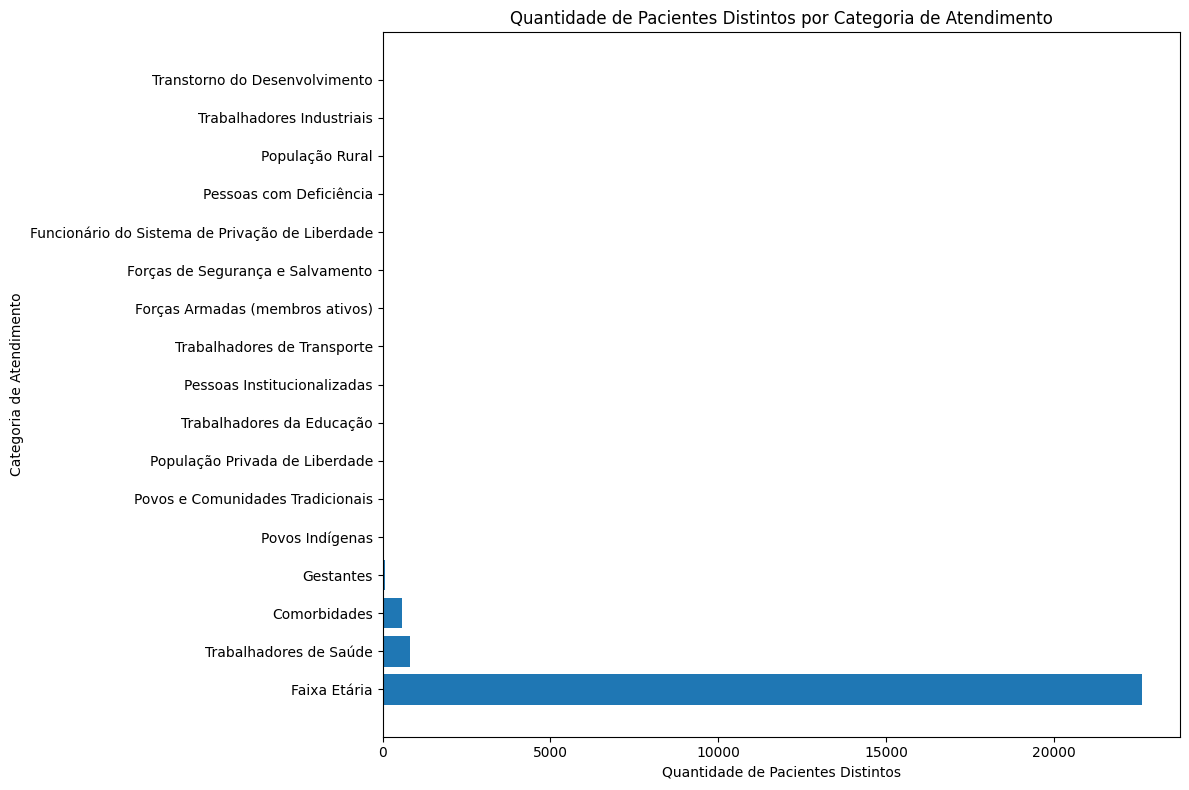

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.barh(
    resultado['categoria'],
    resultado['qtd_pacientes']
)

plt.title('Quantidade de Pacientes Distintos por Categoria de Atendimento')
plt.xlabel('Quantidade de Pacientes Distintos')
plt.ylabel('Categoria de Atendimento')

plt.tight_layout()
plt.show()

2 - Quantidade de pacientes distintos que vacinaram agrupado por Estado;
 Este tópico apresenta a distribuição das vacinas aplicadas entre os estados brasileiros, permitindo identificar regiões com maior cobertura vacinal. A análise auxilia na compreensão de desigualdades regionais e na avaliação da eficiência das campanhas de imunização.

In [ ]:
#2 Pacientes por estado

resultado = df.groupby(
    "nome_uf_estabelecimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["estado", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                 estado  qtd_pacientes
24            SAO PAULO           4849
12         MINAS GERAIS           2428
4                 BAHIA           1621
18       RIO DE JANEIRO           1468
15               PARANA           1440
16           PERNAMBUCO           1184
13                 PARA           1038
23       SANTA CATARINA           1004
20    RIO GRANDE DO SUL            933
8                 GOIAS            914
5                 CEARA            903
3              AMAZONAS            894
9              MARANHAO            868
10          MATO GROSSO            637
7        ESPIRITO SANTO            626
14              PARAIBA            505
1               ALAGOAS            475
17                PIAUI            473
11   MATO GROSSO DO SUL            444
6      DISTRITO FEDERAL            423
19  RIO GRANDE DO NORTE            356
25              SERGIPE            355
21             RONDONIA            303
26            TOCANTINS            244
0                  ACRE  

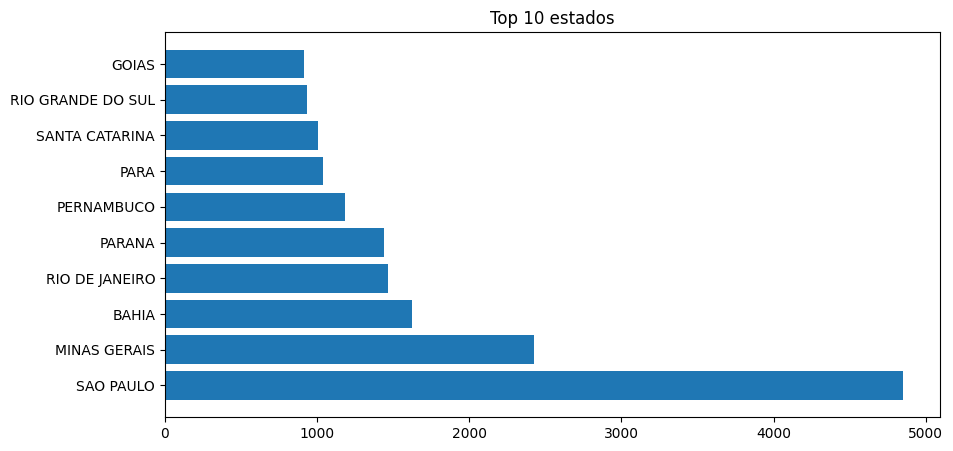

In [ ]:
import matplotlib.pyplot as plt

resultado = df.groupby(
    "nome_uf_estabelecimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["estado", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

top10 = resultado.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10["estado"], top10["qtd_pacientes"])
plt.title("Top 10 estados")
plt.show()


3 - Quantidade de pacientes distintos que vacinaram agrupados por raça e cor;
🧑🏾‍🤝‍🧑🏻 Doses por Raça/Cor

Este gráfico mostra a distribuição das doses aplicadas por raça/cor, com predominância nas categorias parda e branca.

         raca_cor  qtd_pacientes
3           PARDA          11041
1          BRANCA           7691
5  SEM INFORMACAO           4896
0         AMARELA            573
4           PRETA            478
2        INDIGENA             67


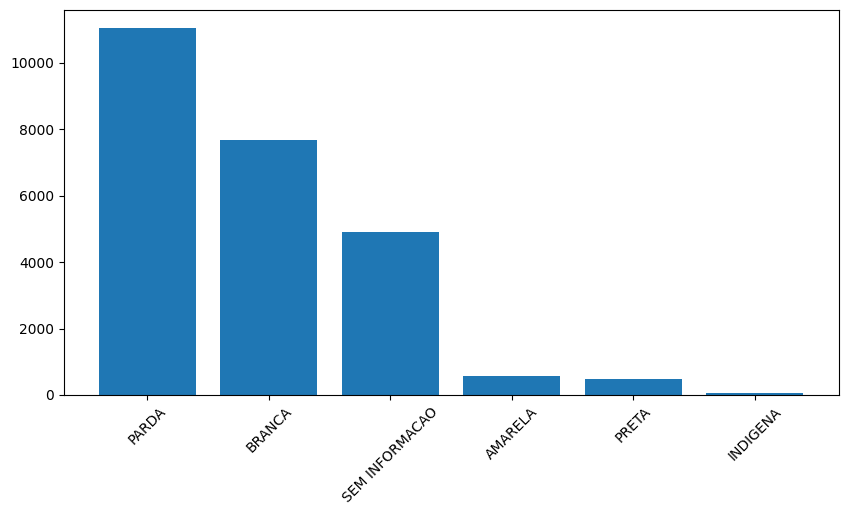

In [ ]:
#3 pacientes agrupados por raça e cor

import matplotlib.pyplot as plt

resultado = df.groupby(
    "nome_raca_cor_paciente"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["raca_cor", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)

plt.figure(figsize=(10,5))
plt.bar(resultado["raca_cor"], resultado["qtd_pacientes"])
plt.xticks(rotation=45)
plt.show()


4- Quantidade de pacientes dististos agrupados por faixa etaria;

A distribuição de pacientes distintos por faixa etária permite identificar quais grupos populacionais foram mais alcançados pela vacinação. Essa análise evidencia padrões importantes, como maior cobertura em públicos prioritários ou maior adesão em determinadas idades, contribuindo para a avaliação da efetividade das estratégias de imunização ao longo do período analisado.

   faixa  qtd_pacientes
0    0-9          13394
1  10-19            238
2  20-29            431
3  30-39            378
4  40-49            384
5  50-59            360
6  60-69            377
7  70-79            287
8  80-89            126
9    90+             26


/tmp/ipykernel_46802/3829580134.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultado = df.groupby("faixa_etaria")["codigo_paciente"].nunique()


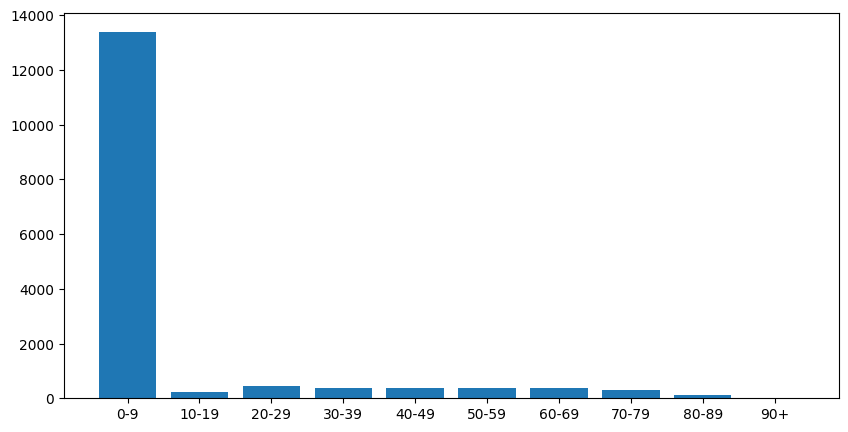

In [ ]:
#4 pacientes agrupados por faixa etaria

import pandas as pd
import matplotlib.pyplot as plt

df["idade"] = pd.to_numeric(
    df["numero_idade_paciente"],
    errors="coerce"
)

bins = [0,9,19,29,39,49,59,69,79,89,200]
labels = ["0-9","10-19","20-29","30-39","40-49","50-59","60-69","70-79","80-89","90+"]

df["faixa_etaria"] = pd.cut(
    df["idade"],
    bins=bins,
    labels=labels
)

resultado = df.groupby("faixa_etaria")["codigo_paciente"].nunique()
resultado = resultado.reset_index()
resultado.columns = ["faixa", "qtd_pacientes"]

print(resultado)

plt.figure(figsize=(10,5))
plt.bar(resultado["faixa"], resultado["qtd_pacientes"])
plt.show()


5- Descrição do tipo de vacina;

Neste gráfico é possível observar que a vacina Pfizer (Comirnaty) foi a mais aplicada no período analisado, seguida por AstraZeneca e CoronaVac. Também aparecem versões específicas como vacinas pediátricas e bivalentes, indicando diversidade de imunizantes utilizados na campanha.

In [ ]:
#5 - descricao_vacina

resultado = df.groupby(
    "descricao_vacina"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["vacina", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                                   vacina  qtd_pacientes
10                        Vacina varicela           9467
7                  Vacina polio injetável           6423
3                    Vacina febre amarela           5205
5                        Vacina meningo C           1445
8    Vacina raiva em cultivo celular vero           1277
6                        Vacina pneumo 23           1014
4                       Vacina hepatite A             80
9                 Vacina sarampo, rubéola             22
2                              Vacina Hib             11
1                      Soro anticrotálico              2
0   Imunoglobulina humana anti-hepatite B              2


6- Quantidade de doses por pacientes distintos;

A análise da quantidade de doses em relação ao número de pacientes distintos permite avaliar o alcance real da vacinação na população. Enquanto o total de doses indica o volume de aplicações realizadas, o número de indivíduos únicos mostra quantas pessoas foram efetivamente atendidas. A diferença entre esses valores reflete a aplicação de esquemas vacinais completos, incluindo doses adicionais e de reforço, sendo um indicador importante da continuidade e efetividade da imunização.

In [ ]:
#6 - descricao_dose_vacina

resultado = df.groupby(
    "descricao_dose_vacina"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["dose", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                                         dose  qtd_pacientes
2                                     2ª Dose          11717
6                                        Dose           4893
12                                    Reforço           2962
0                                     1ª Dose           2902
4                                     3ª Dose           1949
13                                      Única            333
5                                     4ª Dose            109
1                                  1º Reforço             49
8                                   Dose Zero             37
3                                  2º Reforço             14
10  Profilaxia com 10 frascos-ampolas/ampolas              2
9       Profilaxia com 1 frasco-ampola/ampola              2
7                                Dose Inicial              1
11   Profilaxia com 5 frascos-ampolas/ampolas              1


7- Gêneros dos pacientes;

A análise dos gêneros dos pacientes permite compreender a distribuição da vacinação entre os diferentes grupos, evidenciando possíveis diferenças no acesso ou na adesão à imunização. Essa informação é relevante para identificar padrões populacionais e apoiar estratégias mais inclusivas e equitativas nas campanhas de vacinação.

  genero  qtd_pacientes
0      F          12246
1      M          12500


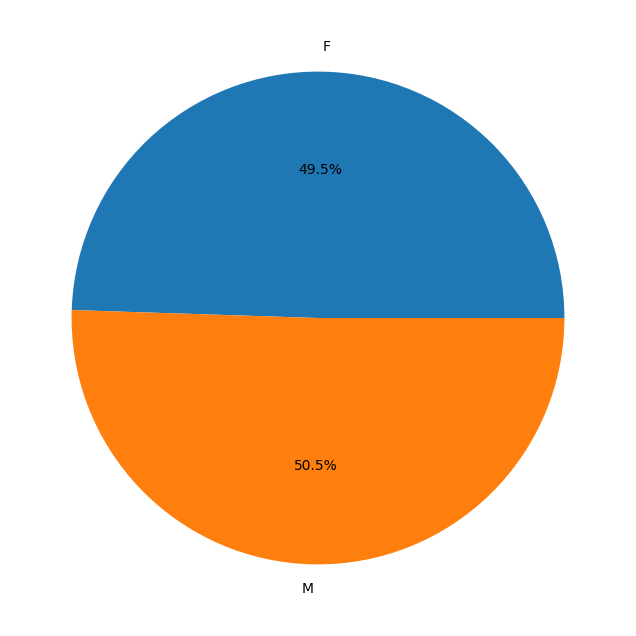

In [ ]:
#7 - tipo_genero_paciente

import matplotlib.pyplot as plt

resultado = df.groupby(
    "tipo_sexo_paciente"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["genero", "qtd_pacientes"]

print(resultado)

plt.figure(figsize=(8,8))
plt.pie(
    resultado["qtd_pacientes"],
    labels=resultado["genero"],
    autopct="%1.1f%%"
)
plt.show()

8- Tipo de estabelecimento;


“Tipo de estabelecimento” é uma classificação usada para identificar a natureza ou atividade principal de um local ou empresa.

In [ ]:
#8 descricao_tipo_estabelecimento

resultado = df.groupby(
    "descricao_tipo_estabelecimento"
).size()

resultado = resultado.reset_index()
resultado.columns = ["tipo_estabelecimento", "quantidade"]

resultado = resultado.sort_values(
    "quantidade",
    ascending=False
)

print(resultado)


                                 tipo_estabelecimento  quantidade
5                      CENTRO DE SAUDE/UNIDADE BASICA       22393
14                                     POSTO DE SAUDE         597
12                                        POLICLINICA         408
3                                CENTRO DE IMUNIZACAO         396
10                                     HOSPITAL GERAL         335
6                     CLINICA/CENTRO DE ESPECIALIDADE         253
15                                 PRONTO ATENDIMENTO         176
0                            CENTRAL DE ABASTECIMENTO          73
21                                      UNIDADE MISTA          71
9                              HOSPITAL ESPECIALIZADO          55
17                               PRONTO SOCORRO GERAL          55
1                          CENTRAL DE GESTAO EM SAUDE          51
19                UNIDADE DE ATENCAO A SAUDE INDIGENA          28
22                              UNIDADE MOVEL FLUVIAL          20
16        